# 🛒 Blinkit Sales & Delivery Analytics
## Python Analysis — EDA & Business Insights

**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Dataset:** 8,500+ Blinkit grocery sales records  

### Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("Libraries loaded ✓")

Libraries loaded ✓


### Step 2 — Load & Inspect Data

In [2]:
df = pd.read_excel('blinkit_grocery_data.xlsx')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
display(df.head())

Shape: (8523, 12)

Columns: ['Item Fat Content', 'Item Identifier', 'Item Type', 'Outlet Establishment Year', 'Outlet Identifier', 'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility', 'Item Weight', 'Sales', 'Rating']

Missing values:
Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64


,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


### Step 3 — Clean Data

In [3]:
df_clean = df.copy()

# Standardise fat content values
fat_map = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
}
df_clean['Item Fat Content'] = (
    df_clean['Item Fat Content'].replace(fat_map)
)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Drop nulls
df_clean = df_clean.dropna()

print(f"Clean dataset: {len(df_clean):,} rows")
print(f"\nFat Content values:")
print(df_clean['Item Fat Content'].value_counts())

Clean dataset: 7,060 rows

Fat Content values:
Item Fat Content
Low Fat    4566
Regular    2494
Name: count, dtype: int64


### Step 4 — Key Business Metrics

In [6]:
print("=" * 45)
print("KEY BUSINESS METRICS")
print("=" * 45)

total_sales  = df_clean['Sales'].sum()
avg_sales    = df_clean['Sales'].mean()
total_items  = len(df_clean)
avg_rating   = df_clean['Rating'].mean()

print(f"Total Sales:         ${total_sales:,.0f}")
print(f"Avg Sales per Item:  ${avg_sales:,.0f}")
print(f"Total Items:         {total_items:,}")
print(f"Avg Rating:          {avg_rating:.2f} / 5")

print("\nSales by Outlet Type:")
outlet_summary = (
    df_clean.groupby('Outlet Type')['Sales']
    .agg(['sum','mean','count'])
    .round(2)
    .sort_values('sum', ascending=False)
)
print(outlet_summary)

print("\nTop 5 Item Types by Sales:")
print(
    df_clean.groupby('Item Type')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

KEY BUSINESS METRICS
Total Sales:         $997,159
Avg Sales per Item:  $141
Total Items:         7,060
Avg Rating:          3.97 / 5

Sales by Outlet Type:
                         sum    mean  count
Outlet Type                                
Supermarket Type1  787549.89  141.21   5577
Supermarket Type2  131477.78  141.68    928
Grocery Store       78131.57  140.78    555

Top 5 Item Types by Sales:
Item Type
Fruits and Vegetables    147188.9632
Snack Foods              144949.1300
Household                113210.1420
Frozen Foods              99961.8818
Dairy                     84526.4968
Name: Sales, dtype: float64


### Step 5 — Visualisations

#### 5a. Sales by Item Type

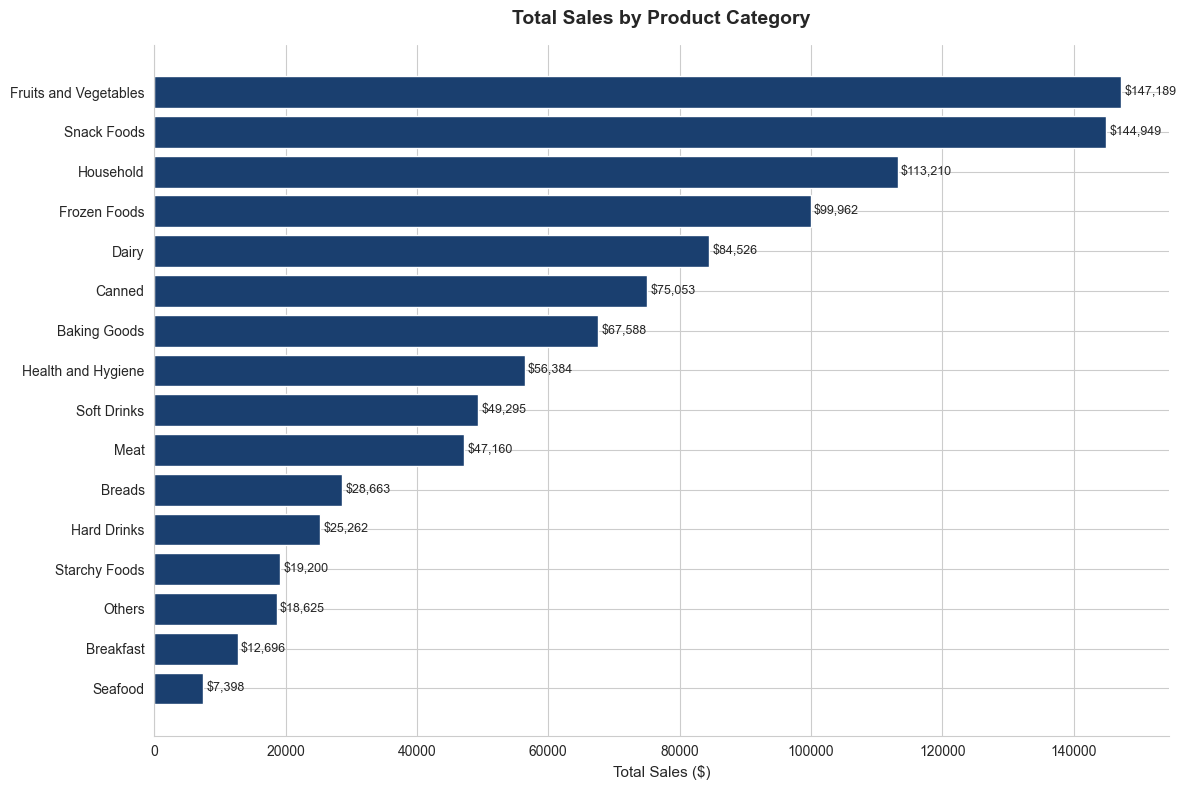

Saved ✓


In [8]:
item_sales = (
    df_clean.groupby('Item Type')['Sales']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    item_sales.index,
    item_sales.values,
    color='#1A3F6F',
    edgecolor='white'
)

for bar, val in zip(bars, item_sales.values):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}',
        va='center', fontsize=9
    )

ax.set_title('Total Sales by Product Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/01_sales_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

#### 5b. Sales by Outlet Type

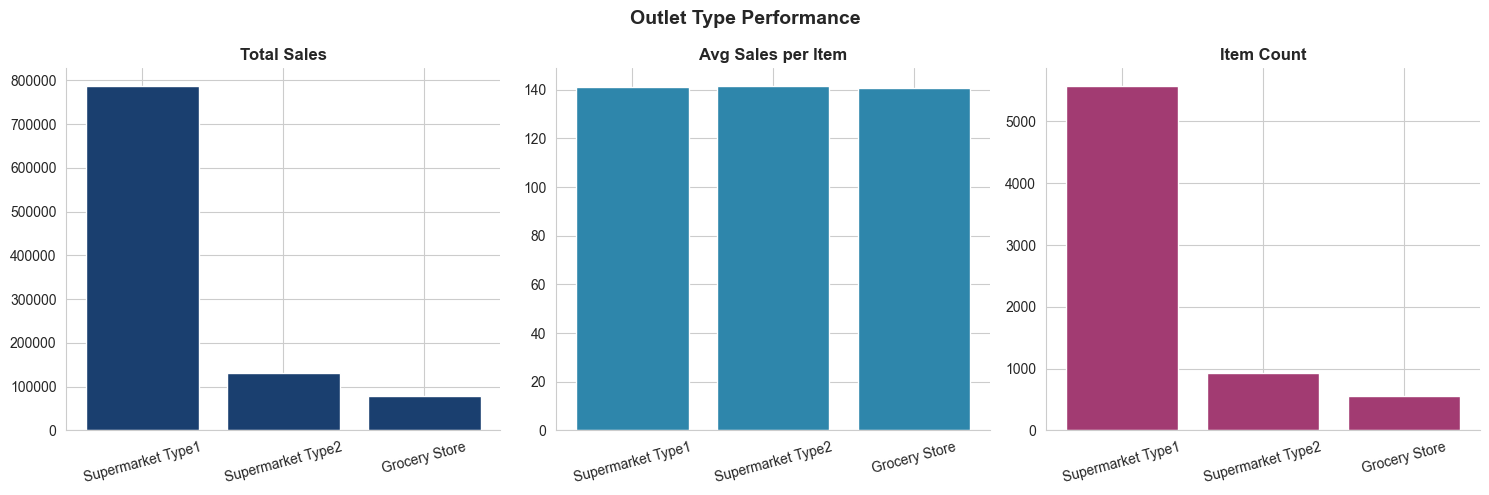

Saved ✓


In [9]:
outlet_sales = (
    df_clean.groupby('Outlet Type')['Sales']
    .agg(['sum','mean','count'])
    .sort_values('sum', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(outlet_sales.index, outlet_sales['sum'],
            color='#1A3F6F')
axes[0].set_title('Total Sales', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(outlet_sales.index, outlet_sales['mean'],
            color='#2E86AB')
axes[1].set_title('Avg Sales per Item', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(outlet_sales.index, outlet_sales['count'],
            color='#A23B72')
axes[2].set_title('Item Count', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Outlet Type Performance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_outlet_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

#### 5c. Fat Content Analysis

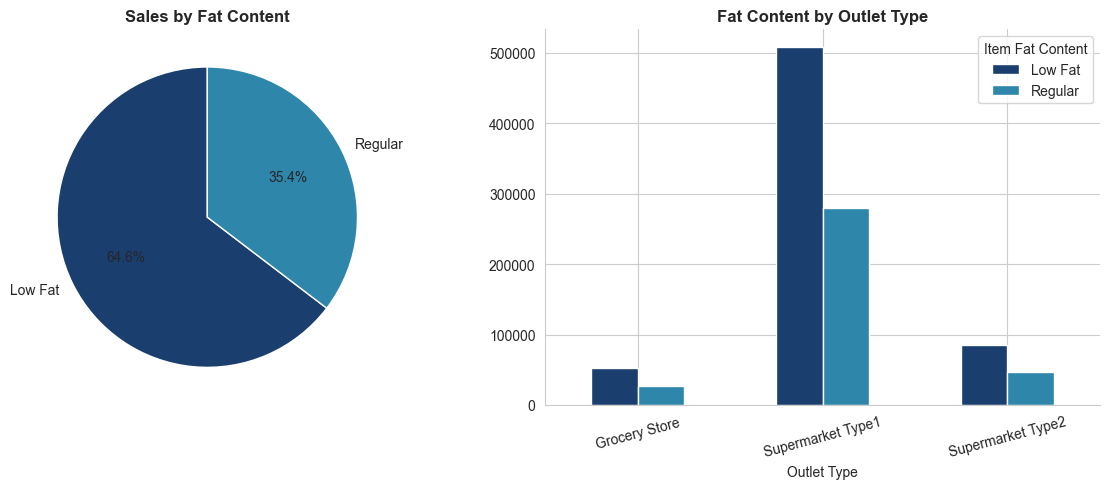

Saved ✓


In [12]:
fat_sales = (
    df_clean.groupby('Item Fat Content')['Sales']
    .sum()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    fat_sales.values,
    labels=fat_sales.index,
    autopct='%1.1f%%',
    colors=['#1A3F6F','#2E86AB'],
    startangle=90
)
axes[0].set_title('Sales by Fat Content',
                  fontweight='bold')

fat_outlet = (
    df_clean.groupby(
        ['Outlet Type','Item Fat Content']
    )['Sales']
    .sum()
    .unstack()
)
fat_outlet.plot(
    kind='bar', ax=axes[1],
    color=['#1A3F6F','#2E86AB'],
    edgecolor='white'
)
axes[1].set_title('Fat Content by Outlet Type',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/03_fat_content.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

#### 5d. Sales by Location Tier

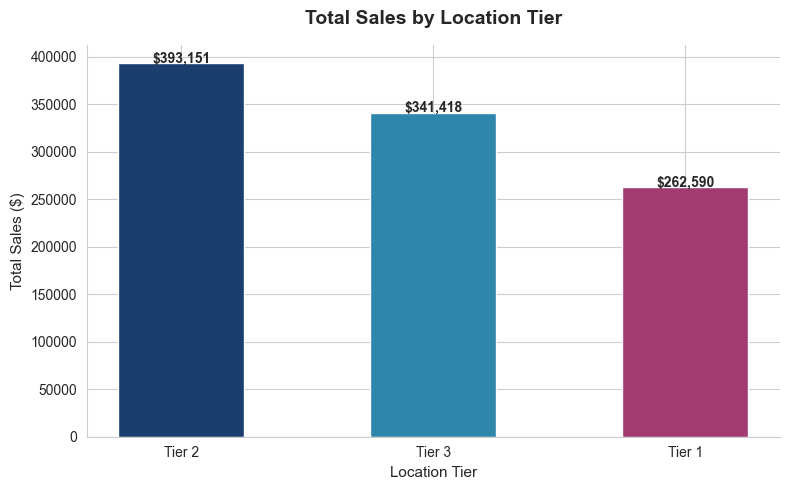

Saved ✓


In [13]:
tier_sales = (
    df_clean.groupby('Outlet Location Type')
    ['Sales']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    tier_sales.index,
    tier_sales.values,
    color=['#1A3F6F','#2E86AB','#A23B72'],
    width=0.5,
    edgecolor='white'
)

for bar, val in zip(bars, tier_sales.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'${val:,.0f}',
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Total Sales by Location Tier',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Location Tier', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/04_location_tier.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

#### 5e. Outlet Establishment Year vs Sales

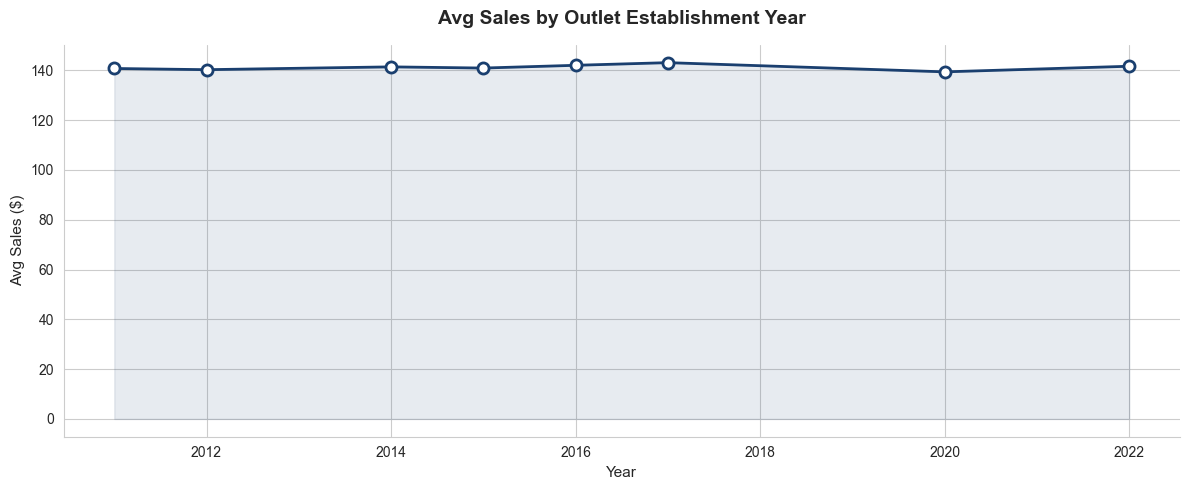

Saved ✓


In [15]:
year_sales = (
    df_clean.groupby('Outlet Establishment Year')
    ['Sales']
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    year_sales.index,
    year_sales.values,
    marker='o', linewidth=2,
    color='#1A3F6F', markersize=8,
    markerfacecolor='white',
    markeredgewidth=2
)
ax.fill_between(
    year_sales.index,
    year_sales.values,
    alpha=0.1, color='#1A3F6F'
)

ax.set_title(
    'Avg Sales by Outlet Establishment Year',
    fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Avg Sales ($)', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/05_establishment_year.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

### Step 6 — Conclusions & Recommendations

In [16]:
print("""
CONCLUSIONS
===========

1. TOP CATEGORY
   Fruits & Vegetables and Snack Foods drive
   the highest revenue. Stock and promote these
   categories aggressively.

2. OUTLET TYPE PERFORMANCE
   Supermarket Type 1 generates the most total
   sales. Expanding this format in underserved
   areas would drive growth.

3. FAT CONTENT TREND
   Low Fat items consistently outsell Regular
   items — reflecting India's growing health
   consciousness. Prioritise Low Fat variants.

4. LOCATION OPPORTUNITY
   Tier 3 cities show strong sales — indicating
   quick-commerce demand beyond metros. Expansion
   here represents untapped opportunity.

5. ESTABLISHMENT AGE
   Older outlets tend to have higher average
   sales — loyalty and trust build over time.
   Customer retention programmes matter.
""")


CONCLUSIONS

1. TOP CATEGORY
   Fruits & Vegetables and Snack Foods drive
   the highest revenue. Stock and promote these
   categories aggressively.

2. OUTLET TYPE PERFORMANCE
   Supermarket Type 1 generates the most total
   sales. Expanding this format in underserved
   areas would drive growth.

3. FAT CONTENT TREND
   Low Fat items consistently outsell Regular
   items — reflecting India's growing health
   consciousness. Prioritise Low Fat variants.

4. LOCATION OPPORTUNITY
   Tier 3 cities show strong sales — indicating
   quick-commerce demand beyond metros. Expansion
   here represents untapped opportunity.

5. ESTABLISHMENT AGE
   Older outlets tend to have higher average
   sales — loyalty and trust build over time.
   Customer retention programmes matter.



### Step 7 — Export Clean Data

In [17]:
df_clean.to_csv('outputs/blinkit_clean.csv', index=False)

print("Exported files:")
print("  outputs/blinkit_clean.csv           ✓")
print("  outputs/01_sales_by_category.png    ✓")
print("  outputs/02_outlet_performance.png   ✓")
print("  outputs/03_fat_content.png          ✓")
print("  outputs/04_location_tier.png        ✓")
print("  outputs/05_establishment_year.png   ✓")
print("\nAnalysis complete ✓")

Exported files:
  outputs/blinkit_clean.csv           ✓
  outputs/01_sales_by_category.png    ✓
  outputs/02_outlet_performance.png   ✓
  outputs/03_fat_content.png          ✓
  outputs/04_location_tier.png        ✓
  outputs/05_establishment_year.png   ✓

Analysis complete ✓
